# Analyse de Corrélation et Matrice Heatmap
**Objectif :** Identifier les relations entre les variables numériques de la base de données.

### Questions auxquelles nous répondons :
* Est-ce que le prix d'achat influence directement la quantité commandée ?
* Existe-t-il une corrélation entre les niveaux de stock et le prix de vente ?
* Comment les différentes métriques de prix (MSRP vs BuyPrice) sont-elles liées ?

La matrice de corrélation varie de **-1** (corrélation inverse parfaite) à **+1** (corrélation positive parfaite).

Extraction des données pour corrélation...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


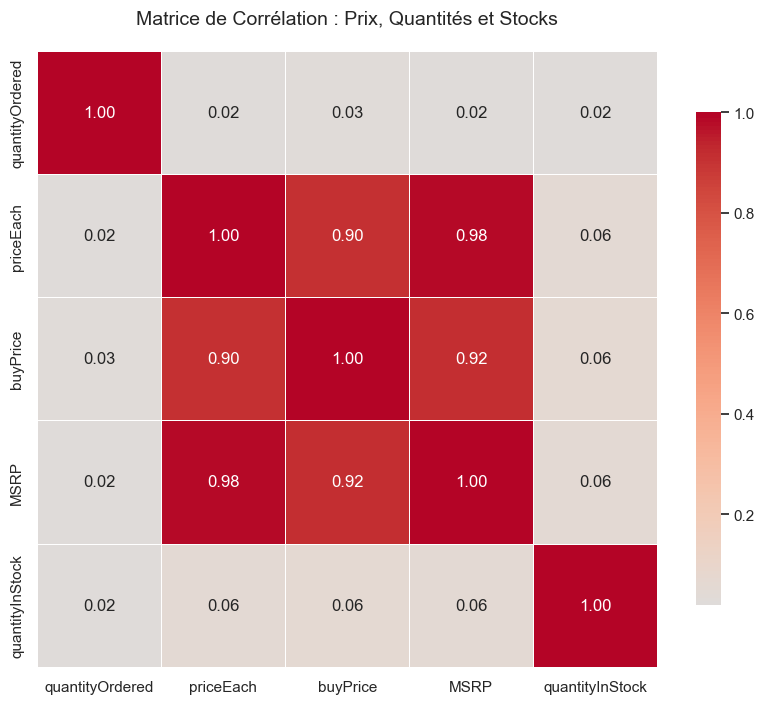

Heatmap sauvegardée dans : ..\visualisations\correlation_heatmap.png


In [3]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION DU CHEMIN
sys.path.append(os.path.abspath(os.path.join('..')))
from src.analysis.connection import get_db_data 

# 2. EXTRACTION DES DONNÉES
# On récupère les colonnes numériques clés de la table orderdetails et products
print("Extraction des données pour corrélation...")
query_corr = """
    SELECT 
        od.quantityOrdered, 
        od.priceEach, 
        p.buyPrice, 
        p.MSRP, 
        p.quantityInStock
    FROM orderdetails od
    JOIN products p ON od.productCode = p.productCode
"""
df_corr = get_db_data(query_corr)

# 3. CALCUL DE LA MATRICE DE CORRÉLATION
correlation_matrix = df_corr.corr()

# 4. VISUALISATION AVEC HEATMAP
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Création de la Heatmap
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,          # Affiche les valeurs numériques
    fmt=".2f",           # Format à 2 décimales
    cmap='coolwarm',     # Couleur bleu (négatif) à rouge (positif)
    center=0, 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Matrice de Corrélation : Prix, Quantités et Stocks', fontsize=14, pad=20)

# Sauvegarde de l'image
save_path_corr = os.path.join('..', 'visualisations', 'correlation_heatmap.png')
plt.savefig(save_path_corr, bbox_inches='tight', dpi=300)
plt.show()

print(f"Heatmap sauvegardée dans : {save_path_corr}")

/ Analyse de la Matrice de Corrélation : Prix, Quantités et Stocks
L'objectif de cette analyse est de quantifier la force des relations entre nos variables clés pour identifier des dépendances critiques ou, au contraire, des déconnexions dans notre stratégie commerciale.

1. Analyse des Liaisons Fortes (Structure Tarifaire)
Alignement MSRP / Prix de vente (0.98) : On observe une corrélation quasi parfaite entre le prix conseillé (MSRP) et le prix réellement pratiqué (priceEach). Cela démontre que ClassicModels suit rigoureusement les recommandations de prix du marché, laissant peu de place à une guerre des prix agressive.

Marge et Coûts (0.90 - 0.92) : La forte corrélation entre le buyPrice (prix d'achat) et le prix de vente confirme une politique de marge stable. L'entreprise ne semble pas pratiquer de prix d'appel à perte, mais applique un coefficient constant sur ses achats.

2. Analyse des Liaisons Faibles (Elasticité et Logistique)
Indépendance du Volume (0.02 - 0.03) : Fait marquant, il n'y a aucune corrélation entre le prix d'un article et la quantité commandée.

--> Interprétation métier : Nos clients n'achètent pas "moins" parce que c'est "plus cher". Cela suggère que nous vendons des produits de collection ou de niche où la valeur émotionnelle prime sur le prix. Nous disposons donc d'un certain pouvoir de fixation des prix (Pricing Power).

- Gestion des Stocks (0.06) : La corrélation quasi nulle entre le stock disponible et les ventes (quantityOrdered) ou le prix est un point d'attention.

--> Interprétation métier : Le niveau de stock semble déconnecté du succès commercial immédiat des produits. Nous risquons de sur-stocker des articles coûteux qui tournent peu, ou d'être en sous-stock sur des articles à forte rotation.